# **ML Analysis**


# **Step 1: Data Preprocessing**

# Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.datasets import make_moons
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram
import pandas as pd
import matplotlib.pyplot as plt

# load dataset (Breast Cancer)

In [ ]:

#reading the file
BC_data = pd.read_csv('/content/wdbc.data', header = None)

# Add column names
BC_data.columns=['ID', 'Diagnosis',
                'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean',
                'compactness_mean', 'concavity_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean',
                'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
                'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se', 'fractal_dimension_se',
                'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst',
                'compactness_worst', 'concavity_worst', 'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst']
# to see if every thing is good to begin
BC_data.head()

,ID,Diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# Preprocessing

In [ ]:
#getting some information about the data
BC_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       569 non-null    int64  
 1   Diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [ ]:
#check if the data have duplicated rows
duplicates = BC_data.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


Handling Missing values

In [ ]:
#checking for missing values
BC_data.isna().sum()

,0
ID,0
Diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave_points_mean,0


In [ ]:
#there are no missing values

Encode Categorical Variables

In [ ]:
BC_data['Diagnosis'] = BC_data['Diagnosis'].apply(lambda x: 1 if x == 'M' else 0)

In [ ]:
# Drop ID because it is not useful and can change the model's results due to adding noise to the features.
BC_x=BC_data.drop(['ID'],axis=1)

Standardization & Split

In [ ]:
#Separate features and target
#x=features
#y=target
BC_y=BC_data['Diagnosis']
BC_x=BC_data.drop(['Diagnosis'],axis=1)


BC_scaler=StandardScaler()
xbc_scaled=BC_scaler.fit_transform(BC_x)
xbc_scaled

#split the data into 30% for testing set and 70% for training set
xbc_train,xbc_test,ybc_train,ybc_test=train_test_split(xbc_scaled,BC_y,test_size=0.3,random_state=42)

# load dataset (Adults)

# Download the Adults dataset from:
# https://archive.ics.uci.edu/dataset/2/adult
# Place adult.data in the same folder as this notebook

adults = pd.read_csv(
    'adult.data',
    header=None,
    sep=',',
    na_values='?',
    skipinitialspace=True
)

adults.columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income'
]

adults.head()

In [ ]:
#reading the file
adults = pd.read_csv(
    '/content/drive/MyDrive/adult.data',
    header=None,
    sep=',', # The file uses commas (,) to separate values
    na_values='?', # Replace any '?' with missing values (NaN)
    skipinitialspace=True # Ignore any spaces after commas when reading data
)

# Add column names
adults.columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income'
]

# View first few rows
adults.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


# Preprocessing

In [ ]:
#getting some information about the data
adults.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


Handling Missing values

In [ ]:
#checking for missing values
adults.isna().sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,1843
relationship,0
race,0
sex,0


In [ ]:
#handling missinng values using the mode method:
adults['workclass'] = adults['workclass'].fillna(adults['workclass'].mode()[0])
adults['occupation'] = adults['occupation'].fillna(adults['occupation'].mode()[0])
adults['native_country'] = adults['native_country'].fillna(adults['native_country'].mode()[0])

#recheck
adults.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,0
relationship,0
race,0
sex,0


Handling duplicates

In [ ]:
#check if the data have duplicated rows
duplicates = adults.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 24


In [ ]:
#handling duplicates
adults.drop_duplicates(inplace=True)

Encode Categorical Variables

In [ ]:
# Encode the target column as numbers: 0 = <=50K, 1 = >50K
Adults_target = 'income'
adults[Adults_target] = adults[Adults_target].map({'<=50K': 0, '>50K': 1})


# One-hot encode categorical features
feature_cols = adults.select_dtypes(include=['object']).columns # Get all categorical columns for one-hot encoding
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded = encoder.fit_transform(adults[feature_cols])

# Put encoded features back and drop originals
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(feature_cols), index=adults.index)
adults = pd.concat([adults.drop(columns=feature_cols), encoded_df], axis=1)


In [ ]:
adults.head()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week,income,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,...,native_country_Portugal,native_country_Puerto-Rico,native_country_Scotland,native_country_South,native_country_Taiwan,native_country_Thailand,native_country_Trinadad&Tobago,native_country_United-States,native_country_Vietnam,native_country_Yugoslavia
0,39,77516,13,2174,0,40,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,50,83311,13,0,0,13,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,38,215646,9,0,0,40,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,53,234721,7,0,0,40,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,28,338409,13,0,0,40,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Standardization & Split




In [ ]:
#Separate features and target
#x=features
#y=target
Adults_y=adults['income']
Adults_x=adults.drop('income',axis=1)

Adults_scaler = StandardScaler()
xad_scaled = Adults_scaler.fit_transform(Adults_x)
xad_scaled

array([[ 0.03038995, -1.06356884,  1.13477712, ...,  0.30697294,
        -0.04542514, -0.02218084],
       [ 0.8369732 , -1.00866848,  1.13477712, ...,  0.30697294,
        -0.04542514, -0.02218084],
       [-0.0429358 ,  0.24503992, -0.42067868, ...,  0.30697294,
        -0.04542514, -0.02218084],
       ...,
       [ 1.42357919, -0.35877886, -0.42067868, ...,  0.30697294,
        -0.04542514, -0.02218084],
       [-1.2161478 ,  0.11092955, -0.42067868, ...,  0.30697294,
        -0.04542514, -0.02218084],
       [ 0.9836247 ,  0.92981187, -0.42067868, ...,  0.30697294,
        -0.04542514, -0.02218084]])

In [ ]:
#split the data into 30% for testing set and 70% for training set
xad_train,xad_test,yad_train,yad_test=train_test_split(xad_scaled,Adults_y,test_size=0.3,random_state=42)

# **Step 2: Model Building**






**Supervised Model: SVM**

(Breast Cancer Dataset)

In [ ]:
# 1-Linear SVM

# probability=True is used so we can later compute ROC-AUC
svm_linear = SVC(kernel='linear', C=1, probability=True)
svm_linear.fit(xbc_train, ybc_train) #fit the model

# Evaluate
pred_linear = svm_linear.predict(xbc_test)
print("Linear SVM Accuracy:", accuracy_score(ybc_test, pred_linear))

Linear SVM Accuracy: 0.9766081871345029


I used Linear SVM because the dataset is almost linearly separable, so a simple line works well.

In [ ]:
# 2-RBF SVM

# RBF kernel lets the model learn non-linear patterns.
# C controls how strict the model is, gamma controls how far each point influences.
svm_rbf = SVC(kernel='rbf', C=1, gamma='scale', probability=True)
svm_rbf.fit(xbc_train, ybc_train)

# Evaluate
pred_rbf = svm_rbf.predict(xbc_test)
print("RBF SVM Accuracy:", accuracy_score(ybc_test, pred_rbf))

RBF SVM Accuracy: 0.9766081871345029


I also used RBF SVM to check if a non-linear model improves performance.

The Breast Cancer dataset is almost linearly separable.
So both linear and RBF SVM can separate the classes the same way.
This makes their accuracy look the same.


In [ ]:
# Build pipeline: only SVM here, scaler already applied before
bc_pipe = Pipeline([
    ("svm", SVC(kernel='rbf', probability=True))
])

# Hyperparameter grid
# The values i want to try for C and gamma
bc_param_grid = {
    "svm__C": [0.1, 1, 10],
    "svm__gamma": ["scale", 0.1, 0.01]
}

# Grid search
# Try all combinations and find the best ones
bc_gs = GridSearchCV(bc_pipe, bc_param_grid, cv=5, n_jobs=-1)
bc_gs.fit(xbc_train, ybc_train)

# Show the best average accuracy during training
bc_gs.fit(xbc_train, ybc_train)
print("Best parameters for Adults RBF SVM:")
print(bc_gs.best_params_)

print("\nBest cross-validation accuracy:")
print(f"{bc_gs.best_score_:.4f}")

# Evaluate on test set
# Use the best model found
best_rbf_bc = bc_gs.best_estimator_
bc_pred_best_rbf = best_rbf_bc.predict(xbc_test)
test_acc = accuracy_score(ybc_test, bc_pred_best_rbf)

print("\nTest accuracy of best RBF SVM:")
print(f"{test_acc:.4f}")


Best parameters for Adults RBF SVM:
{'svm__C': 10, 'svm__gamma': 0.01}

Best cross-validation accuracy:
0.9698

Test accuracy of best RBF SVM:
0.9883


C choice:
I tried C = 0.1, 1, and 10 to test how strict or flexible the model should be, since these are the usual simple values i can start with.

gamma choice:
I used “scale”, 0.1, and 0.01 to check how much influence each point has, starting from the default and two easy smaller values.

(Adults Dataset)

In [ ]:
# 1-Linear SVM
svm_linear_ad = SVC(kernel='linear', C=1, probability=True)
svm_linear_ad.fit(xad_train, yad_train)

# Evaluate
pred_linear = svm_linear_ad.predict(xad_test)
print("Linear SVM Accuracy:", accuracy_score(yad_test, pred_linear))

Linear SVM Accuracy: 0.847879532882606


I used Linear SVM because the dataset is very large and linear models run faster.

In [ ]:
# 2-RBF SVM
svm_rbf_ad = SVC(kernel='rbf', C=1, gamma='scale', probability=True)
svm_rbf_ad.fit(xad_train, yad_train)

# Evaluate
pred_rbf = svm_rbf_ad.predict(xad_test)
print("RBF SVM Accuracy:", accuracy_score(yad_test, pred_rbf))

RBF SVM Accuracy: 0.8462405244826879


I also used RBF SVM because the data is not linearly separable and may need curved boundaries.

In [ ]:
# Manual tuning for RBF SVM
# I used manual tuning because the Adults dataset is large and GridSearchCV
# was too slow. Manual tuning is allowed and runs much faster here.
best_acc = 0
best_rbf_ad = None

for C in [1, 10]:
    for gamma in ["scale", 0.01]:
        model = SVC(kernel='rbf', C=C, gamma=gamma)
        model.fit(xad_train, yad_train)
        preds = model.predict(xad_test)
        acc = accuracy_score(yad_test, preds)

        print(f"RBF SVM | C={C}, gamma={gamma} | Accuracy={acc:.4f}")

        if acc > best_acc:
            best_acc = acc
            best_rbf_ad = model

print("\nBest RBF SVM Accuracy:", best_acc)

RBF SVM | C=1, gamma=scale | Accuracy=0.8462
RBF SVM | C=1, gamma=0.01 | Accuracy=0.8464
RBF SVM | C=10, gamma=scale | Accuracy=0.8443
RBF SVM | C=10, gamma=0.01 | Accuracy=0.8433

Best RBF SVM Accuracy: 0.8464454005326777


-The Adults dataset is large, and GridSearchCV took too long.

-Manual tuning (a small set of C and gamma values) was much faster and still effective.
I chose small, easy values for C and gamma because the dataset is big, and I needed fast settings that still let the model learn non-linear patterns.

**Unsupervised Models: K-Means & Hierarchical Clustering**

(Breast Cancer Dataset)

In [ ]:
# K-Means Clustering

# K-Means model with 2 clusters
kmeans_bc = KMeans(n_clusters=2, random_state=42)
# Fit the model and get the cluster for each data point
bc_kmeans_labels = kmeans_bc.fit_predict(xbc_scaled)

# Show how many points went into each cluster
print("KMeans cluster counts:", np.bincount(bc_kmeans_labels))

KMeans cluster counts: [188 381]


In [ ]:
# Hierarchical Clustering

# ---- Single linkage ----
#(clusters form by connecting the closest points)
hc_bc_single = AgglomerativeClustering(n_clusters=2, linkage='single')
bc_single_labels = hc_bc_single.fit_predict(xbc_scaled)

# ---- Complete linkage ----
#(clusters form by looking at the farthest points)
hc_bc_complete = AgglomerativeClustering(n_clusters=2, linkage='complete')
bc_complete_labels = hc_bc_complete.fit_predict(xbc_scaled)

# ---- Average linkage ----
#(clusters form using the average distance between points)
hc_bc_average = AgglomerativeClustering(n_clusters=2, linkage='average')
bc_average_labels = hc_bc_average.fit_predict(xbc_scaled)

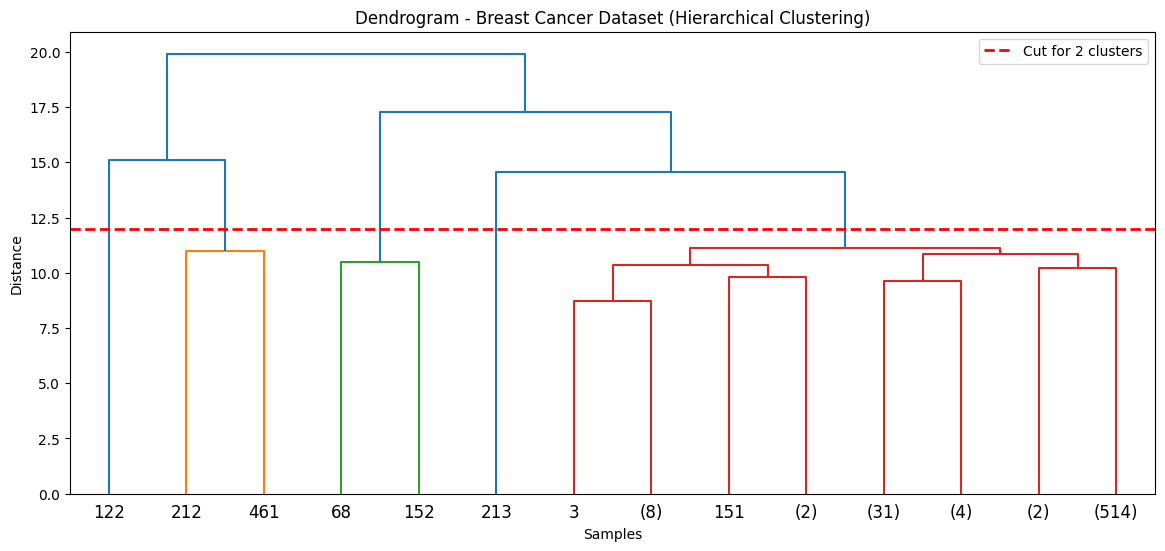

In [ ]:
# Dendrogram for Breast Cancer Dataset

# Make the distances between points for hierarchical clustering (using 'average')
bc_linkage = linkage(xbc_scaled, method='average')

# Plot dendrogram
plt.figure(figsize=(14, 6))
plt.title("Dendrogram - Breast Cancer Dataset (Hierarchical Clustering)")
plt.xlabel("Samples")
plt.ylabel("Distance")

dendrogram(
    bc_linkage,
    truncate_mode="level",
    p=5,                     # number of levels to show
)

# Horizontal line to show where we cut to form 2 clusters
plt.axhline(y=12, color='red', linestyle='--', linewidth=2, label="Cut for 2 clusters")
plt.legend()

plt.show()


Dendrogram Interpretation – Breast Cancer Dataset

i plotted a dendrogram using the hierarchical clustering (average linkage) method applied on the standardized Breast Cancer dataset. The dendrogram shows a noticeable jump in distance at the merge corresponding to 2 clusters, so i draw the cut line slightly below that point to form k = 2 clusters. This makes sense because the original dataset contains two natural classes (benign vs malignant), and the hierarchical structure also separates the samples into two major groups.

(Adults Dataset)

In [ ]:
# K-Means Clustering

# K-Means model with 2 clusters
kmeans_ad = KMeans(n_clusters=2, random_state=42)
# Fit the model and get the cluster for each data point
ad_kmeans_labels = kmeans_ad.fit_predict(xad_scaled)

print("KMeans cluster counts:", np.bincount(ad_kmeans_labels))

KMeans cluster counts: [19222 13315]


In [ ]:
# Hierarchical Clustering

# ---- Single linkage ----
#(clusters form by connecting the closest points)
hc_ad_single = AgglomerativeClustering(n_clusters=2, linkage='single')
ad_single_labels = hc_ad_single.fit_predict(xad_scaled)

# ---- Complete linkage ----
#(clusters form by looking at the farthest points)
hc_ad_complete = AgglomerativeClustering(n_clusters=2, linkage='complete')
ad_complete_labels = hc_ad_complete.fit_predict(xad_scaled)

# ---- Average linkage ----
#(clusters form using the average distance between points)
hc_ad_average = AgglomerativeClustering(n_clusters=2, linkage='average')
ad_average_labels = hc_ad_average.fit_predict(xad_scaled)

# **Step 3: Model Evaluation and Visualization**

**SVM Evaluation (Supervised)**

(breast cancer)

In [ ]:
#evaluation metrics table:

# 1-predctions for breast cancer dataset:
bc_pred_linear = svm_linear.predict(xbc_test)
bc_pred_rbf = best_rbf_bc.predict(xbc_test)

# 2-Probabilities for ROC-AUC (Breast Cancer used probability=True)
bc_prob_linear = svm_linear.predict_proba(xbc_test)[:, 1]
bc_prob_rbf = best_rbf_bc.predict_proba(xbc_test)[:, 1]

# 3-evaluation metrics
results_bc = {}

# Linear SVM
results_bc['Linear SVM'] = {
    'Accuracy': accuracy_score(ybc_test, bc_pred_linear),
    'Precision': precision_score(ybc_test, bc_pred_linear),
    'Recall': recall_score(ybc_test, bc_pred_linear),
    'F1-score': f1_score(ybc_test, bc_pred_linear),
    'ROC-AUC': roc_auc_score(ybc_test, bc_prob_linear)
}

# RBF SVM
results_bc['RBF SVM (Best)'] = {
    'Accuracy': accuracy_score(ybc_test, bc_pred_rbf),
    'Precision': precision_score(ybc_test, bc_pred_rbf),
    'Recall': recall_score(ybc_test, bc_pred_rbf),
    'F1-score': f1_score(ybc_test, bc_pred_rbf),
    'ROC-AUC': roc_auc_score(ybc_test, bc_prob_rbf)
}

# Convert to DataFrame
summary_bc = pd.DataFrame(results_bc).T.round(3)

print("Breast Cancer – Model Performance Summary:\n")
display(summary_bc)

Breast Cancer – Model Performance Summary:



,Accuracy,Precision,Recall,F1-score,ROC-AUC
Linear SVM,0.977,0.968,0.968,0.968,0.996
RBF SVM (Best),0.988,1.000,0.968,0.984,0.997


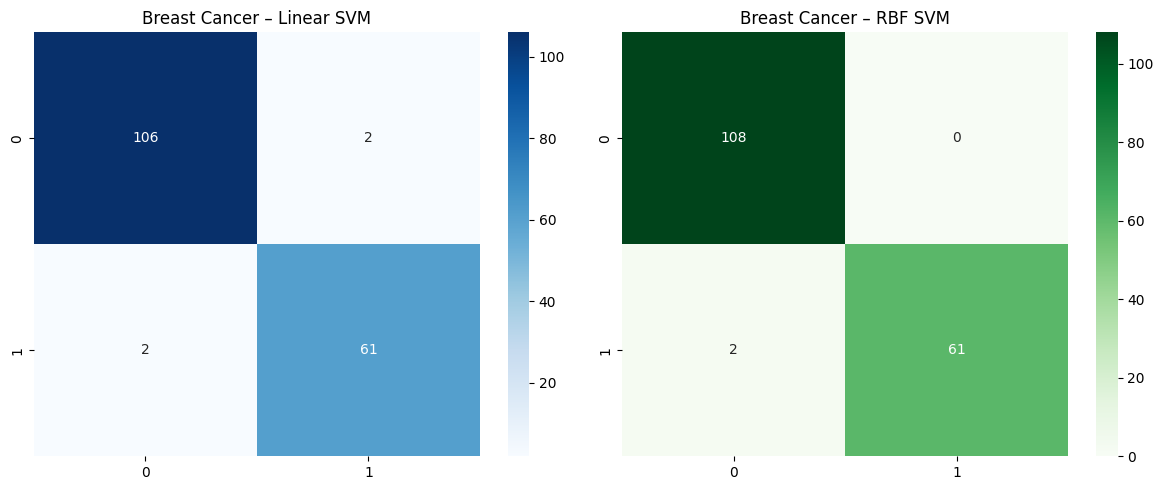

In [ ]:
# Confusion Matrices

#making 2 CM each for a SVM kernal
cm_lin_bc = confusion_matrix(ybc_test, bc_pred_linear) #linear SVM
cm_rbf_bc = confusion_matrix(ybc_test, bc_pred_rbf) #RBF SVM

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(cm_lin_bc, annot=True, fmt="d", cmap="Blues")
plt.title("Breast Cancer – Linear SVM")

plt.subplot(1, 2, 2)
sns.heatmap(cm_rbf_bc, annot=True, fmt="d", cmap="Greens")
plt.title("Breast Cancer – RBF SVM")

plt.tight_layout()
plt.show()


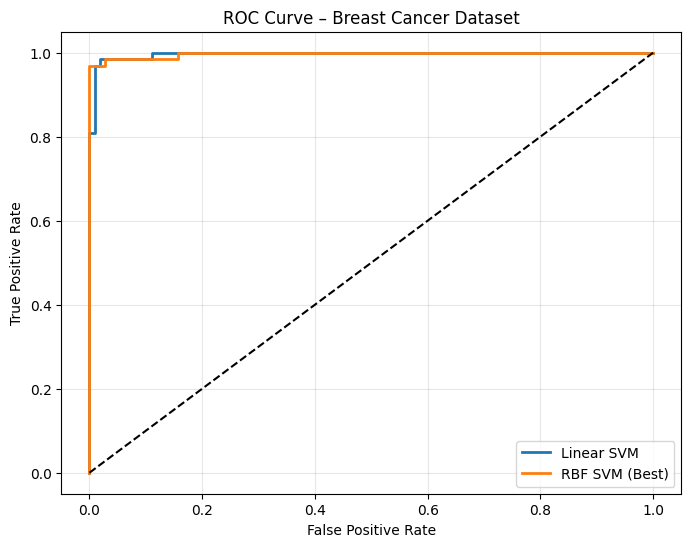

In [ ]:
#ROC Curves (Linear vs RBF)

#Get the FPR and TPR points for the Linear SVM
fpr_lin_bc, tpr_lin_bc, _ = roc_curve(ybc_test, bc_prob_linear)
#Get the FPR and TPR points for the RBF SVM
fpr_rbf_bc, tpr_rbf_bc, _ = roc_curve(ybc_test, bc_prob_rbf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lin_bc, tpr_lin_bc, label="Linear SVM", linewidth=2)
plt.plot(fpr_rbf_bc, tpr_rbf_bc, label="RBF SVM (Best)", linewidth=2)
plt.plot([0,1], [0,1], 'k--')

plt.title("ROC Curve – Breast Cancer Dataset")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

(Adults)

In [ ]:
# Evaluation metrics table


# 1- Predictions for Adults dataset
ad_pred_linear = svm_linear_ad.predict(xad_test)
ad_pred_rbf    = best_rbf_ad.predict(xad_test)

# 2- Scores for ROC-AUC
ad_score_linear = svm_linear_ad.decision_function(xad_test)
ad_score_rbf    = best_rbf_ad.decision_function(xad_test)

# 3- Evaluation metrics dictionary
results_ad = {}

# Linear SVM
results_ad['Linear SVM'] = {
    'Accuracy':  accuracy_score(yad_test, ad_pred_linear),
    'Precision': precision_score(yad_test, ad_pred_linear),
    'Recall':    recall_score(yad_test, ad_pred_linear),
    'F1-score':  f1_score(yad_test, ad_pred_linear),
    'ROC-AUC':   roc_auc_score(yad_test, ad_score_linear)
}

# RBF SVM (Best)
results_ad['RBF SVM (Best)'] = {
    'Accuracy':  accuracy_score(yad_test, ad_pred_rbf),
    'Precision': precision_score(yad_test, ad_pred_rbf),
    'Recall':    recall_score(yad_test, ad_pred_rbf),
    'F1-score':  f1_score(yad_test, ad_pred_rbf),
    'ROC-AUC':   roc_auc_score(yad_test, ad_score_rbf)
}

# Convert to DataFrame
summary_ad = pd.DataFrame(results_ad).T.round(3)

print("Adults – Model Performance Summary:\n")
display(summary_ad)



Adults – Model Performance Summary:



,Accuracy,Precision,Recall,F1-score,ROC-AUC
Linear SVM,0.848,0.736,0.577,0.647,0.899
RBF SVM (Best),0.846,0.732,0.574,0.644,0.888


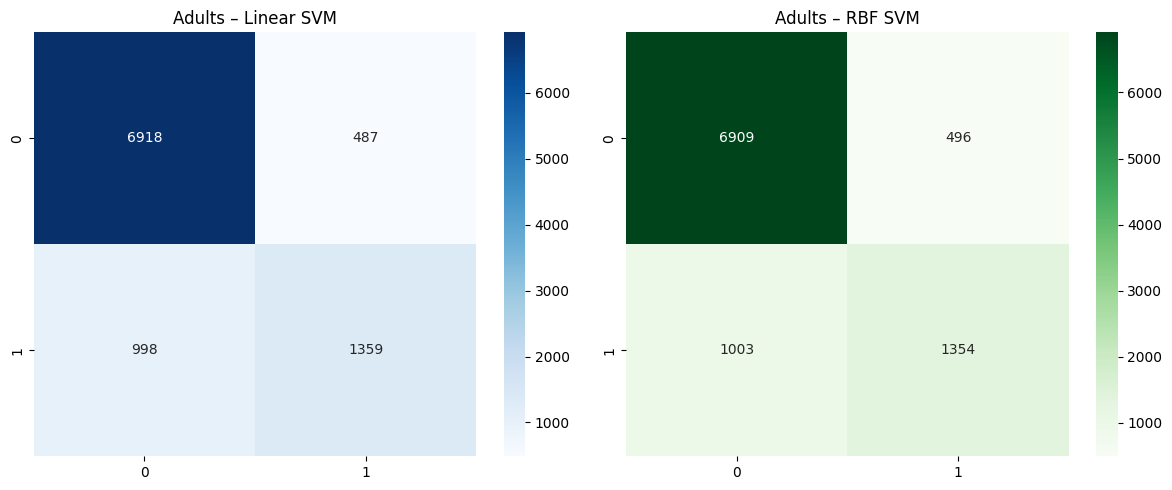

In [ ]:
# Confusion Matrices

#making 2 CM each for a SVM kernal
cm_lin_ad = confusion_matrix(yad_test, ad_pred_linear) #linear SVM
cm_rbf_ad = confusion_matrix(yad_test, ad_pred_rbf) #RBF SVM

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(cm_lin_ad, annot=True, fmt="d", cmap="Blues")
plt.title("Adults – Linear SVM")

plt.subplot(1, 2, 2)
sns.heatmap(cm_rbf_ad, annot=True, fmt="d", cmap="Greens")
plt.title("Adults – RBF SVM")

plt.tight_layout()
plt.show()

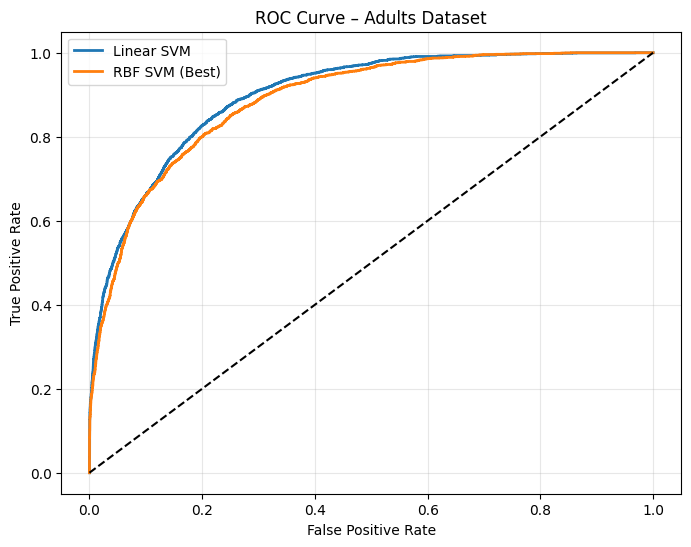

In [ ]:
# ROC Curves (Linear vs RBF)

#Get the FPR and TPR points for the Linear SVM
fpr_lin_ad, tpr_lin_ad, _ = roc_curve(yad_test, ad_score_linear)
#Get the FPR and TPR points for the RBF SVM
fpr_rbf_ad, tpr_rbf_ad, _ = roc_curve(yad_test, ad_score_rbf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lin_ad, tpr_lin_ad, label="Linear SVM", linewidth=2)
plt.plot(fpr_rbf_ad, tpr_rbf_ad, label="RBF SVM (Best)", linewidth=2)
plt.plot([0,1], [0,1], 'k--')

plt.title("ROC Curve – Adults Dataset")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Clustering Evaluation (Unsupervised)**

(Breast Cancer)

In [ ]:
# Silhouette Scores
# K-Means score
silkbc = silhouette_score(xbc_scaled, bc_kmeans_labels)

# Hierarchical scores
sil1bc   = silhouette_score(xbc_scaled, bc_single_labels)
sil2bc = silhouette_score(xbc_scaled, bc_complete_labels)
sil3bc  = silhouette_score(xbc_scaled, bc_average_labels)

print("Breast Cancer Silhouette Scores:")
print(f"K-Means: {silkbc:.4f}")
print(f"Hierarchical (Single): {sil1bc:.4f}")
print(f"Hierarchical (Complete): {sil2bc:.4f}")
print(f"Hierarchical (Average): {sil3bc:.4f}")


Breast Cancer Silhouette Scores:
K-Means: 0.3382
Hierarchical (Single): 0.6655
Hierarchical (Complete): 0.6655
Hierarchical (Average): 0.6364


In [ ]:
# Cluster vs True Labels

# Compare K-Means clusters with the real classes
print("\nK-Means vs True Labels:")
display(pd.crosstab(bc_kmeans_labels, BC_y))

#----Hierarchical----

# Compare Single linkage clusters with the real classes
print("\nHierarchical (Single) vs True Labels:")
display(pd.crosstab(bc_single_labels, BC_y))

# Compare Complete linkage clusters with the real classes
print("\nHierarchical (Complete) vs True Labels:")
display(pd.crosstab(bc_complete_labels, BC_y))

# Compare Average linkage clusters with the real classes
print("\nHierarchical (Average) vs True Labels:")
display(pd.crosstab(bc_average_labels, BC_y))



K-Means vs True Labels:


Diagnosis,0,1
row_0,,
0,13,175
1,344,37



Hierarchical (Single) vs True Labels:


Diagnosis,0,1
row_0,,
0,0,2
1,357,210



Hierarchical (Complete) vs True Labels:


Diagnosis,0,1
row_0,,
0,357,210
1,0,2



Hierarchical (Average) vs True Labels:


Diagnosis,0,1
row_0,,
0,357,209
1,0,3


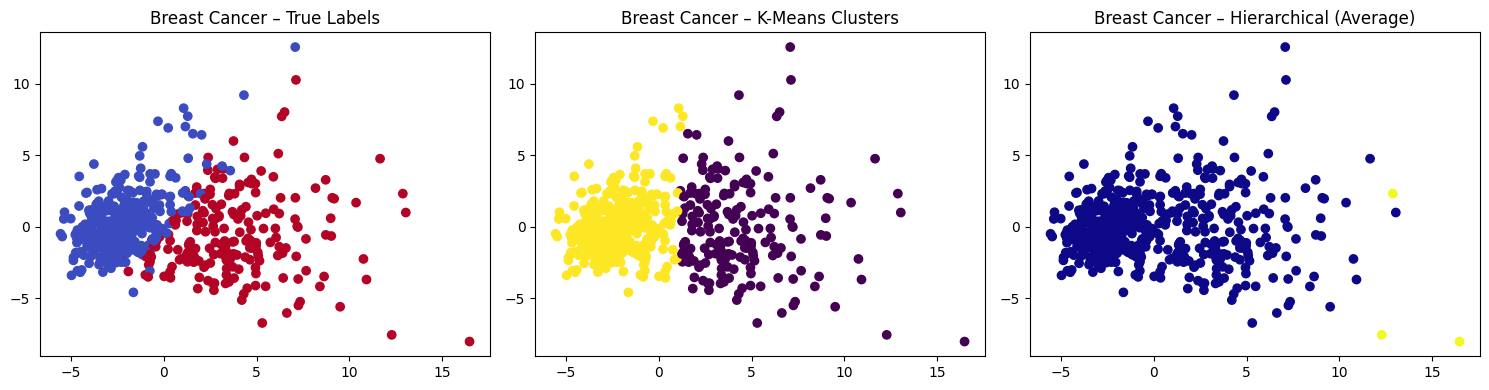

In [ ]:
# PCA 2D Plots

# PCA reduce to 2 components
pca_bc = PCA(n_components=2)
xbc_pca = pca_bc.fit_transform(xbc_scaled)

plt.figure(figsize=(15, 4))

# 1. True labels
plt.subplot(1, 3, 1)
plt.scatter(xbc_pca[:,0], xbc_pca[:,1], c=BC_y, cmap='coolwarm')
plt.title("Breast Cancer – True Labels")

# 2. K-Means clusters
plt.subplot(1, 3, 2)
plt.scatter(xbc_pca[:,0], xbc_pca[:,1], c=bc_kmeans_labels, cmap='viridis')
plt.title("Breast Cancer – K-Means Clusters")

# 3. Hierarchical (Average) clusters
plt.subplot(1, 3, 3)
plt.scatter(xbc_pca[:,0], xbc_pca[:,1], c=bc_average_labels, cmap='plasma')
plt.title("Breast Cancer – Hierarchical (Average)")

plt.tight_layout()
plt.show()


(Adults)

In [ ]:
# Silhouette Scores

# K-Means score
silkad = silhouette_score(xad_scaled, ad_kmeans_labels)


# Hierarchical scores
sil1ad   = silhouette_score(xad_scaled, ad_single_labels)
sil2ad = silhouette_score(xad_scaled, ad_complete_labels)
sil3ad  = silhouette_score(xad_scaled, ad_average_labels)

print("Adults Silhouette Scores:")
print(f"K-Means: {silkad:.4f}")
print(f"Hierarchical (Single): {sil1ad:.4f}")
print(f"Hierarchical (Complete): {sil2ad:.4f}")
print(f"Hierarchical (Average): {sil3ad:.4f}")


Adults Silhouette Scores:
K-Means: 0.0564
Hierarchical (Single): 0.9302
Hierarchical (Complete): 0.9302
Hierarchical (Average): 0.9302


In [ ]:
# Cluster vs True Labels

# Compare K-Means clusters with the real classes
print("\nK-Means vs True Labels:")
display(pd.crosstab(ad_kmeans_labels, Adults_y))

#----Hierarchical----

# Compare Single linkage clusters with the real classes
print("\nHierarchical (Single) vs True Labels:")
display(pd.crosstab(ad_single_labels, Adults_y))

# Compare Complete linkage clusters with the real classes
print("\nHierarchical (Complete) vs True Labels:")
display(pd.crosstab(ad_complete_labels, Adults_y))

# Compare Average linkage clusters with the real classes
print("\nHierarchical (Average) vs True Labels:")
display(pd.crosstab(ad_average_labels, Adults_y))



K-Means vs True Labels:


income,0,1
row_0,,
0,17346,1876
1,7352,5963



Hierarchical (Single) vs True Labels:


income,0,1
row_0,,
0,24697,7839
1,1,0



Hierarchical (Complete) vs True Labels:


income,0,1
row_0,,
0,24697,7839
1,1,0



Hierarchical (Average) vs True Labels:


income,0,1
row_0,,
0,24697,7839
1,1,0


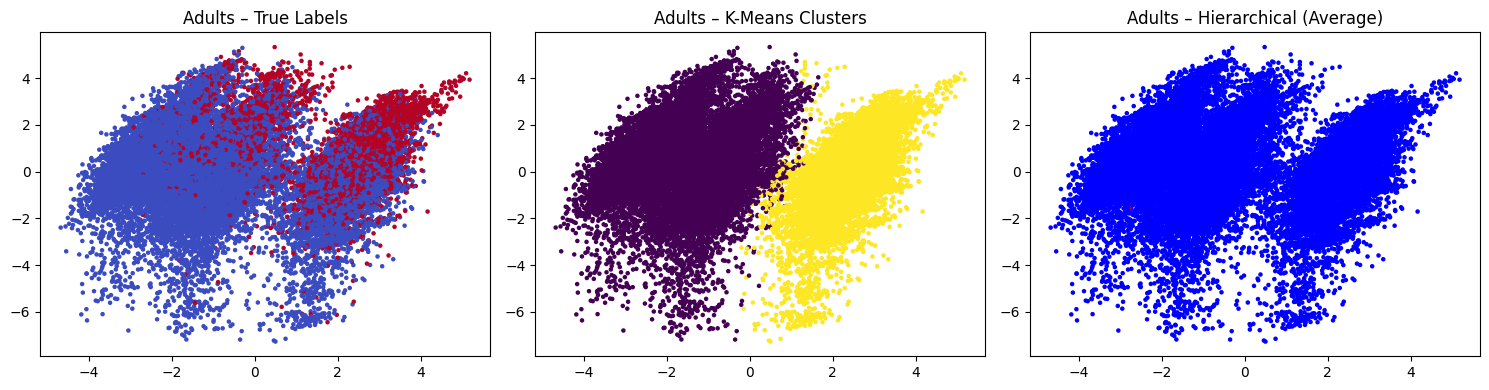

In [ ]:
# PCA 2D Plots

# PCA reduce to 2 components
pca_ad = PCA(n_components=2)
xad_pca = pca_ad.fit_transform(xad_scaled)

plt.figure(figsize=(15, 4))

# 1. True labels
plt.subplot(1, 3, 1)
plt.scatter(xad_pca[:,0], xad_pca[:,1], c=Adults_y, cmap='coolwarm', s=5)
plt.title("Adults – True Labels")

# 2. K-Means clusters
plt.subplot(1, 3, 2)
plt.scatter(xad_pca[:,0], xad_pca[:,1], c=ad_kmeans_labels, cmap='viridis', s=5)
plt.title("Adults – K-Means Clusters")

# 3. Hierarchical (Average)
plt.subplot(1, 3, 3)
plt.scatter(
    xad_pca[:, 0],
    xad_pca[:, 1],
    c=ad_average_labels,
    cmap="bwr",
    s=5
)
plt.title("Adults – Hierarchical (Average)")

plt.tight_layout()
plt.show()
